In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


# ============================================================
# 1. Neural-network components
# ============================================================

def relu(z: np.ndarray) -> np.ndarray:
    """ReLU activation function."""
    return np.maximum(0, z)


def relu_derivative(z: np.ndarray) -> np.ndarray:
    """Derivative of ReLU."""
    return (z > 0).astype(float)


def softmax(z: np.ndarray) -> np.ndarray:
    """
    Numerically stable softmax.

    Converts raw output scores into probabilities whose rows sum to 1.
    """
    shifted_z = z - np.max(z, axis=1, keepdims=True)
    exponentials = np.exp(shifted_z)

    return exponentials / np.sum(
        exponentials,
        axis=1,
        keepdims=True,
    )


def cross_entropy_loss(
    y_true: np.ndarray,
    y_probabilities: np.ndarray,
) -> float:
    """
    Multiclass cross-entropy loss.

    y_true must contain integer class labels:
    0, 1, 2, ...
    """
    number_of_samples = y_true.shape[0]

    correct_class_probabilities = y_probabilities[
        np.arange(number_of_samples),
        y_true,
    ]

    correct_class_probabilities = np.clip(
        correct_class_probabilities,
        1e-12,
        1.0,
    )

    return -np.mean(
        np.log(correct_class_probabilities)
    )


# ============================================================
# 2. Feed-forward neural network
# ============================================================

class FeedForwardNeuralNetwork:
    def __init__(
        self,
        input_size: int,
        hidden_size_1: int,
        hidden_size_2: int,
        output_size: int,
        learning_rate: float = 0.001,
        random_seed: int = 42,
    ) -> None:
        self.learning_rate = learning_rate

        rng = np.random.default_rng(random_seed)

        # He initialization works well with ReLU.
        self.W1 = rng.normal(
            0,
            np.sqrt(2 / input_size),
            size=(input_size, hidden_size_1),
        )
        self.b1 = np.zeros((1, hidden_size_1))

        self.W2 = rng.normal(
            0,
            np.sqrt(2 / hidden_size_1),
            size=(hidden_size_1, hidden_size_2),
        )
        self.b2 = np.zeros((1, hidden_size_2))

        self.W3 = rng.normal(
            0,
            np.sqrt(2 / hidden_size_2),
            size=(hidden_size_2, output_size),
        )
        self.b3 = np.zeros((1, output_size))

    def forward(
        self,
        X: np.ndarray,
    ) -> np.ndarray:
        """
        Perform forward propagation.

        Intermediate values are stored because they are needed
        during backpropagation.
        """
        self.X = X

        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)

        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = relu(self.Z2)

        self.Z3 = self.A2 @ self.W3 + self.b3
        self.probabilities = softmax(self.Z3)

        return self.probabilities

    def backward(
        self,
        y_true: np.ndarray,
    ) -> None:
        """
        Calculate gradients using backpropagation
        and update all weights and biases.
        """
        number_of_samples = y_true.shape[0]

        # Softmax combined with cross-entropy has a convenient gradient.
        dZ3 = self.probabilities.copy()

        dZ3[
            np.arange(number_of_samples),
            y_true,
        ] -= 1

        dZ3 /= number_of_samples

        # Output layer gradients
        dW3 = self.A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        # Second hidden layer gradients
        dA2 = dZ3 @ self.W3.T
        dZ2 = dA2 * relu_derivative(self.Z2)

        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # First hidden layer gradients
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(self.Z1)

        dW1 = self.X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Gradient-descent update
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3

    def predict(
        self,
        X: np.ndarray,
    ) -> np.ndarray:
        """Return the most probable class for every observation."""
        probabilities = self.forward(X)

        return np.argmax(probabilities, axis=1)

    def accuracy(
        self,
        X: np.ndarray,
        y_true: np.ndarray,
    ) -> float:
        predictions = self.predict(X)

        return np.mean(predictions == y_true)

    def train(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_validation: np.ndarray,
        y_validation: np.ndarray,
        epochs: int = 500,
        batch_size: int = 32,
        print_every: int = 25,
        random_seed: int = 42,
    ) -> dict:
        """
        Train the network using mini-batch gradient descent.
        """
        rng = np.random.default_rng(random_seed)

        history = {
            "train_loss": [],
            "validation_loss": [],
            "train_accuracy": [],
            "validation_accuracy": [],
        }

        number_of_samples = X_train.shape[0]

        for epoch in range(1, epochs + 1):

            # Shuffle the training observations each epoch.
            permutation = rng.permutation(number_of_samples)

            X_shuffled = X_train[permutation]
            y_shuffled = y_train[permutation]

            # Mini-batch training
            for start_index in range(
                0,
                number_of_samples,
                batch_size,
            ):
                end_index = start_index + batch_size

                X_batch = X_shuffled[
                    start_index:end_index
                ]
                y_batch = y_shuffled[
                    start_index:end_index
                ]

                self.forward(X_batch)
                self.backward(y_batch)

            # Calculate epoch-level performance.
            train_probabilities = self.forward(X_train)
            train_loss = cross_entropy_loss(
                y_train,
                train_probabilities,
            )
            train_accuracy = np.mean(
                np.argmax(
                    train_probabilities,
                    axis=1,
                ) == y_train
            )

            validation_probabilities = self.forward(
                X_validation
            )
            validation_loss = cross_entropy_loss(
                y_validation,
                validation_probabilities,
            )
            validation_accuracy = np.mean(
                np.argmax(
                    validation_probabilities,
                    axis=1,
                ) == y_validation
            )

            history["train_loss"].append(train_loss)
            history["validation_loss"].append(
                validation_loss
            )
            history["train_accuracy"].append(
                train_accuracy
            )
            history["validation_accuracy"].append(
                validation_accuracy
            )

            if epoch == 1 or epoch % print_every == 0:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Train loss: {train_loss:.4f} | "
                    f"Validation loss: "
                    f"{validation_loss:.4f} | "
                    f"Train accuracy: "
                    f"{train_accuracy:.3f} | "
                    f"Validation accuracy: "
                    f"{validation_accuracy:.3f}"
                )

        return history

### preprocessing

In [4]:
# ============================================================
# 3. Load data
# ============================================================

df = pd.read_csv("social_media_screentime_mental_health_2026.csv")


feature_columns = [
    "low_mood_score_0to27",
    "anxiety_score_0to27",
    "daily_screen_hours",
    "self_esteem_1to10",
    "region",
    "age"
]

target_column = "wellbeing_band"

X = df[feature_columns]
y_text = df[target_column]


# ============================================================
# 4. Convert target labels manually
# ============================================================

class_names = [
    "At-risk",
    "Moderate",
    "Good",
]

class_to_number = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

y = y_text.map(class_to_number).to_numpy()

if np.isnan(y).any():
    raise ValueError(
        "The target column contains an unknown mood label."
    )

y = y.astype(int)


# ============================================================
# 5. Split before fitting preprocessing
# ============================================================

X_train, X_temporary, y_train, y_temporary = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y,
    )
)

X_validation, X_test, y_validation, y_test = (
    train_test_split(
        X_temporary,
        y_temporary,
        test_size=0.50,
        random_state=42,
        stratify=y_temporary,
    )
)


# ============================================================
# 6. Preprocessing
# ============================================================

numeric_features = [
    "low_mood_score_0to27",
    "anxiety_score_0to27",
    "daily_screen_hours",
    "self_esteem_1to10",
    "age",
]

categorical_features = [
    "region",
]

numeric_preprocessor = Pipeline(
    steps=[
        (
            "missing_values",
            SimpleImputer(strategy="median"),
        ),
        (
            "standardization",
            StandardScaler(),
        ),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "missing_values",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "one_hot_encoding",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_preprocessor,
            numeric_features,
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features,
        ),
    ]
)


# Fit preprocessing only on training data.
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_validation_processed = preprocessor.transform(
    X_validation
)

X_test_processed = preprocessor.transform(
    X_test
)

# NumPy calculations should use a consistent floating-point type.
X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float64,
)

X_validation_processed = np.asarray(
    X_validation_processed,
    dtype=np.float64,
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float64,
)

### training

In [3]:
network = FeedForwardNeuralNetwork(
    input_size=X_train_processed.shape[1],
    hidden_size_1=32,
    hidden_size_2=16,
    output_size=len(class_names),
    learning_rate=0.001,
    random_seed=42,
)

history = network.train(
    X_train=X_train_processed,
    y_train=y_train,
    X_validation=X_validation_processed,
    y_validation=y_validation,
    epochs=500,
    batch_size=32,
    print_every=25,
)

Epoch    1 | Train loss: 1.0894 | Validation loss: 1.0585 | Train accuracy: 0.415 | Validation accuracy: 0.432
Epoch   25 | Train loss: 0.5759 | Validation loss: 0.5602 | Train accuracy: 0.794 | Validation accuracy: 0.793
Epoch   50 | Train loss: 0.3933 | Validation loss: 0.3722 | Train accuracy: 0.863 | Validation accuracy: 0.878
Epoch   75 | Train loss: 0.3121 | Validation loss: 0.2852 | Train accuracy: 0.893 | Validation accuracy: 0.917
Epoch  100 | Train loss: 0.2689 | Validation loss: 0.2398 | Train accuracy: 0.914 | Validation accuracy: 0.934
Epoch  125 | Train loss: 0.2410 | Validation loss: 0.2122 | Train accuracy: 0.923 | Validation accuracy: 0.944
Epoch  150 | Train loss: 0.2197 | Validation loss: 0.1927 | Train accuracy: 0.934 | Validation accuracy: 0.948
Epoch  175 | Train loss: 0.2021 | Validation loss: 0.1776 | Train accuracy: 0.941 | Validation accuracy: 0.956
Epoch  200 | Train loss: 0.1869 | Validation loss: 0.1649 | Train accuracy: 0.947 | Validation accuracy: 0.959
E

### final test evaluation

In [6]:
test_predictions = network.predict(
    X_test_processed
)

test_accuracy = np.mean(
    test_predictions == y_test
)

print(f"Test accuracy: {test_accuracy:.3f}")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=class_names,
    )
)

print(
    confusion_matrix(
        y_test,
        test_predictions,
    )
)

Test accuracy: 0.985
              precision    recall  f1-score   support

     At-risk       1.00      0.97      0.99       146
    Moderate       0.98      0.99      0.99       565
        Good       0.99      0.98      0.98       339

    accuracy                           0.98      1050
   macro avg       0.99      0.98      0.98      1050
weighted avg       0.98      0.98      0.98      1050

[[142   4   0]
 [  0 561   4]
 [  0   8 331]]


### plot leatning curves

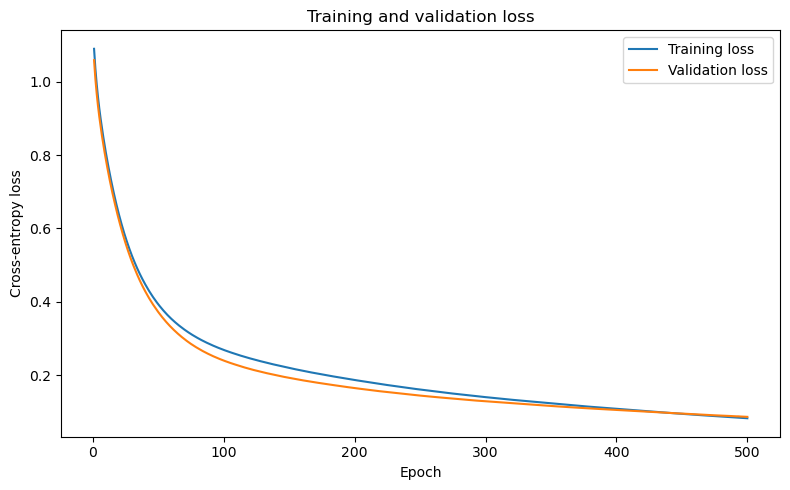

In [16]:
import matplotlib.pyplot as plt


epochs = np.arange(
    1,
    len(history["train_loss"]) + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training loss",
)

plt.plot(
    epochs,
    history["validation_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

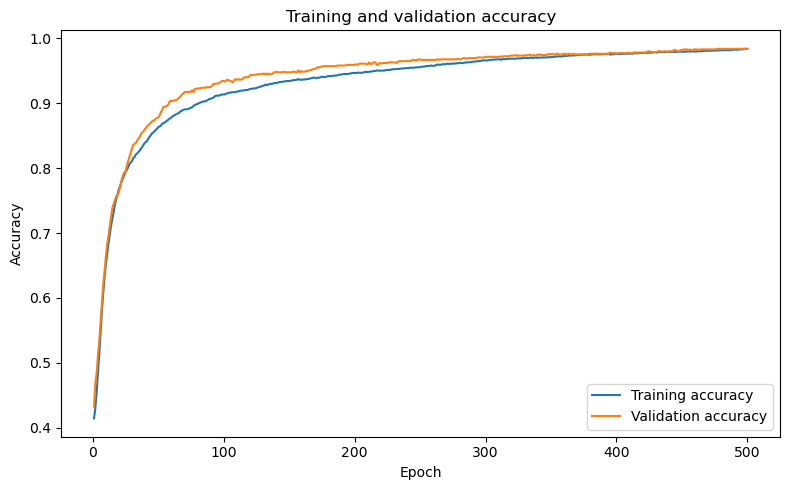

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Training accuracy",
)

plt.plot(
    epochs,
    history["validation_accuracy"],
    label="Validation accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

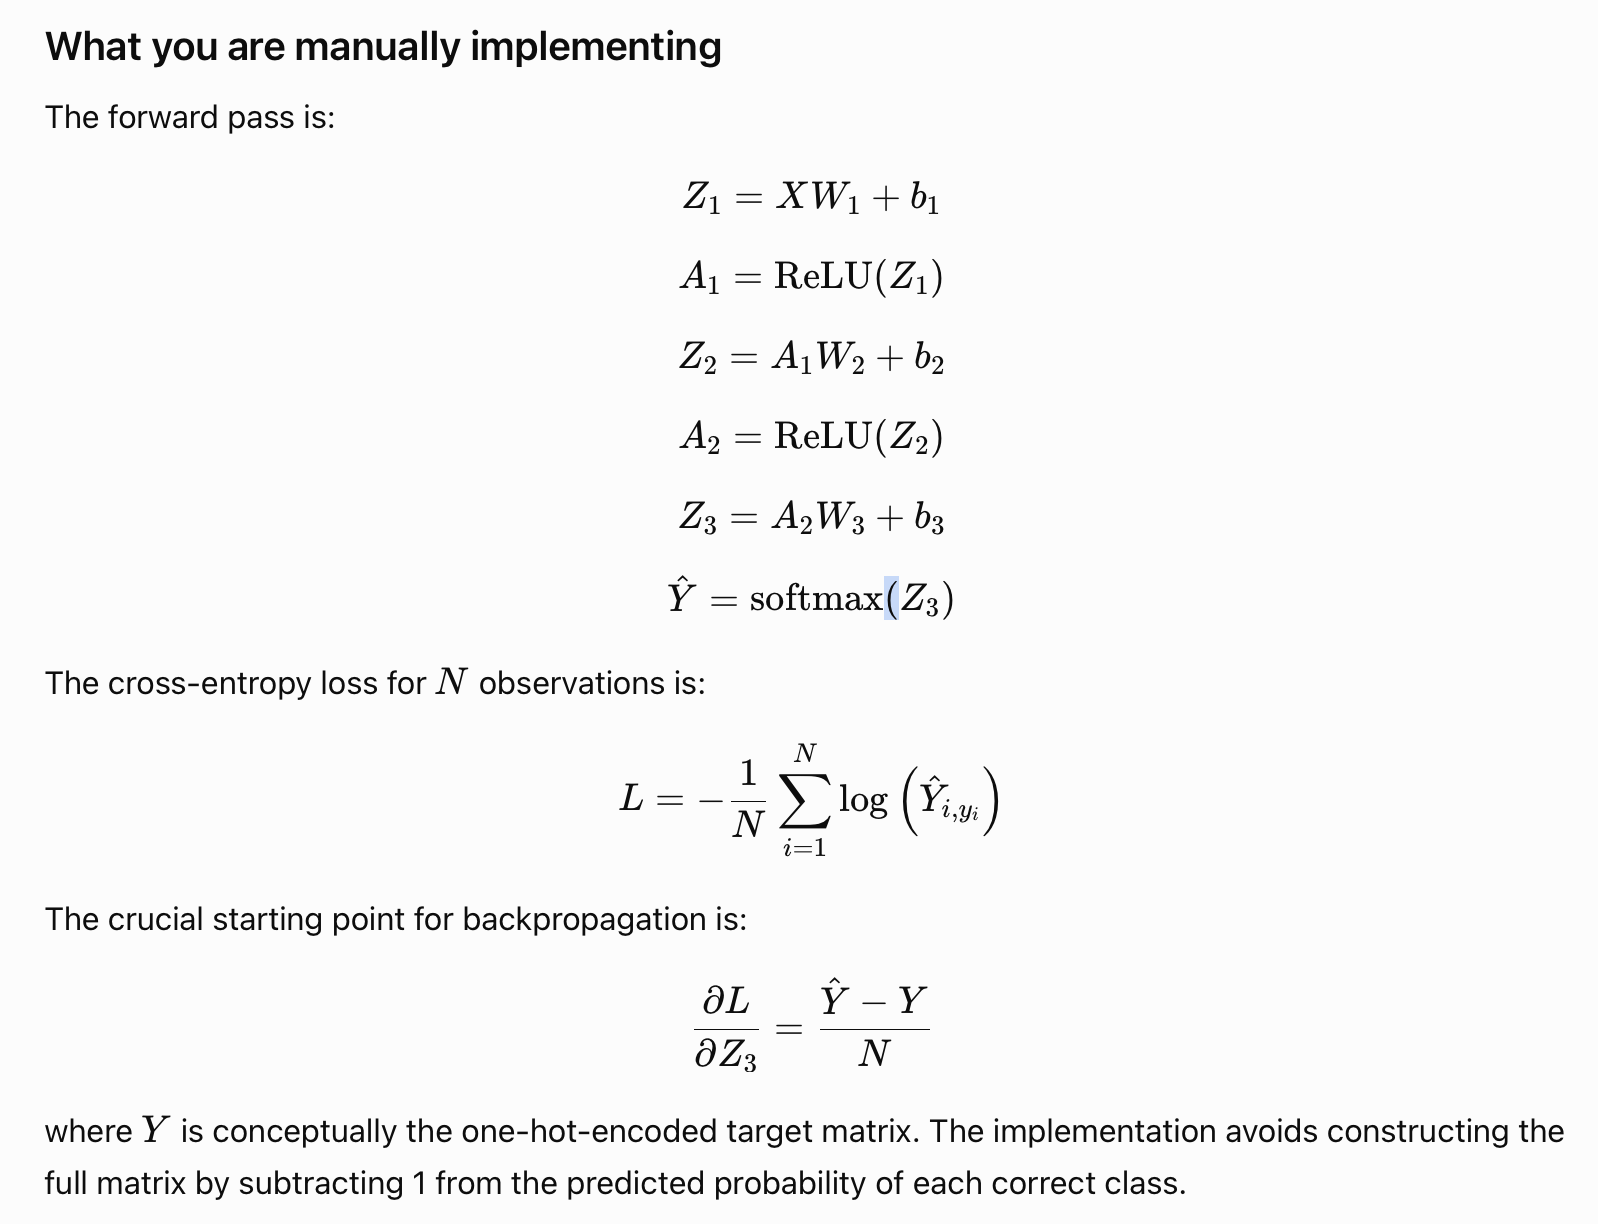